In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [30]:
df = pd.read_csv("../data/AEP_hourly.csv", parse_dates = ['Datetime'])
df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


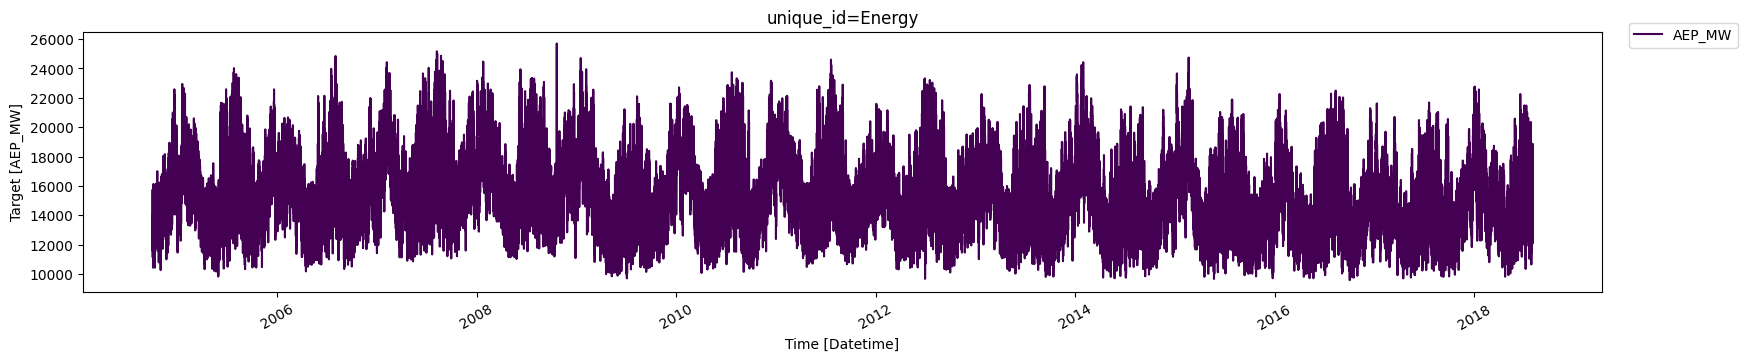

In [31]:
df['unique_id'] = 'Energy'
plot_series(df=df,id_col='unique_id', time_col='Datetime',target_col='AEP_MW' ,palette='viridis')

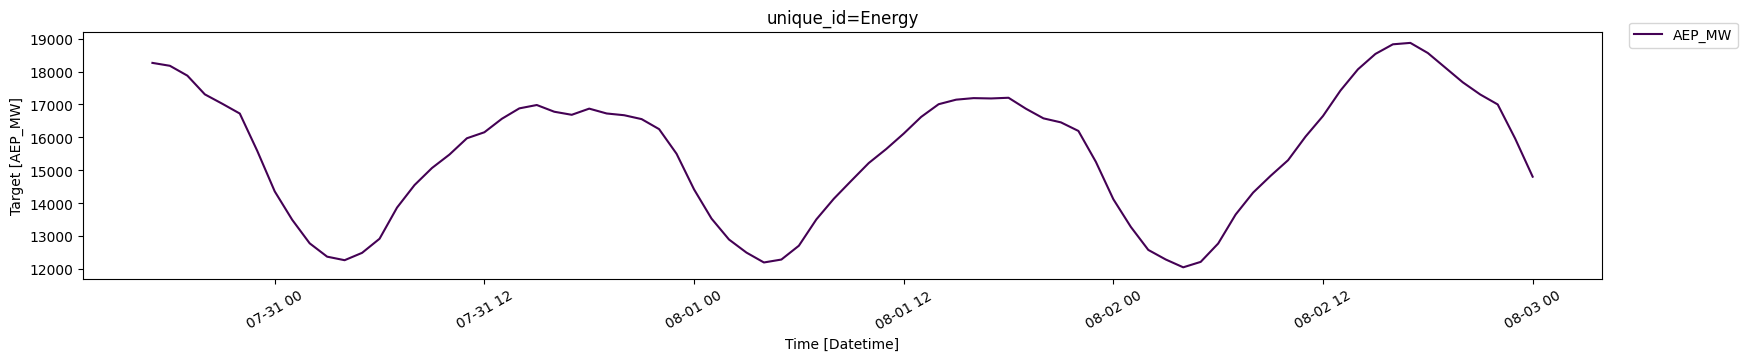

In [32]:
plot_series(df=df,id_col='unique_id', time_col='Datetime',target_col='AEP_MW', max_insample_length=80 ,palette='viridis')

In [33]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

In [44]:
horizon = 7

models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalNaive(season_length=7),
]

sf = StatsForecast(models=models, freq="D")
sf.fit(df=df, id_col='unique_id', time_col='Datetime', target_col='AEP_MW')
preds = sf.predict(h=horizon)

In [45]:
preds.head()

,unique_id,Datetime,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,Energy,2018-08-04,14809.0,15499.513717,17061.428571,18562.0
1,Energy,2018-08-05,14809.0,15499.513717,17061.428571,18118.0
2,Energy,2018-08-06,14809.0,15499.513717,17061.428571,17673.0
3,Energy,2018-08-07,14809.0,15499.513717,17061.428571,17303.0
4,Energy,2018-08-08,14809.0,15499.513717,17061.428571,17001.0


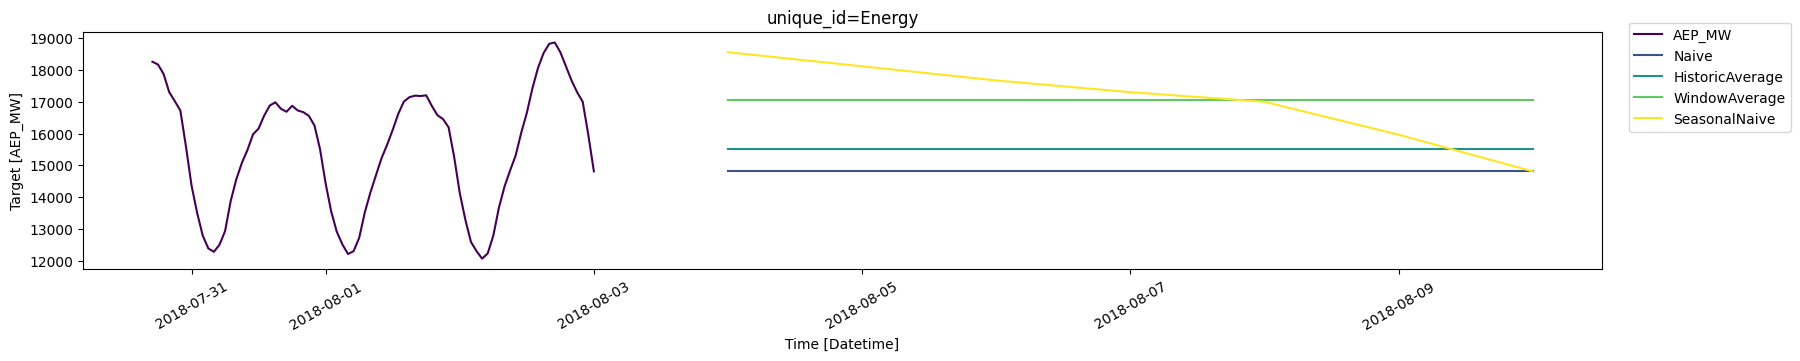

In [46]:
plot_series(df=df,forecasts_df=preds,id_col='unique_id', time_col='Datetime',target_col='AEP_MW', max_insample_length=80 ,palette='viridis')

In [47]:
test = df.groupby("unique_id").tail(7)
train = df.drop(test.index).reset_index(drop=True)

In [50]:
sf.fit(df=train, id_col='unique_id', time_col='Datetime', target_col='AEP_MW')
preds = sf.predict(h=horizon)
eval_df = pd.merge(test, preds, 'left', ['Datetime', 'unique_id'])

In [51]:
evaluation = evaluate(
    eval_df,
    metrics = [mae],
)

evaluation.head()

ColumnNotFoundError: The following columns were not found: ['y']

Hint: Did you mean one of these columns: ['Datetime', 'AEP_MW', 'unique_id', 'Naive', 'HistoricAverage', 'WindowAverage', 'SeasonalNaive']?